# Golden Solution Notebook
### KDD | Kumbhar Digvijay Dagadu | IIT Bombay

**Task:** Given 10 hours of raw voltage/current sensor data from the Volt3X DC power supply
(9V nominal, 600mA limit), this notebook:

1. Loads and validates raw sensor data from `data/` folder
2. Detects and handles sensor dropouts (NaN / I²C timeout events)
3. Reconstructs a stable nominal baseline using only clean data
4. Detects and classifies all 5 fault types with physically-motivated thresholds
5. Calculates energy wasted per fault event (deviation from nominal — not total power)
6. Reports the **total wasted energy in Joules** as the final verifiable answer
7. Passes all 8 unit tests that Gemini's notebook failed

**Run all cells top to bottom. All 8 unit tests must pass.**


## Cell 0 — Generate Dataset

In [39]:
import numpy as np
import pandas as pd
import os

os.makedirs('data', exist_ok=True)
np.random.seed(42)

n_samples = 36000
dt        = 1.0
time      = np.arange(n_samples) * dt

V_NOMINAL = 9.0
I_NOMINAL = 0.400
I_LIMIT   = 0.600

voltage = np.random.normal(V_NOMINAL, 0.015, n_samples)
current = np.random.normal(I_NOMINAL, 0.003, n_samples)

fault_log = []

# Voltage Droop — 3 events
for s, d in [(1200,45),(8500,60),(22000,30)]:
    voltage[s:s+d] -= np.random.uniform(0.8, 1.5)
    current[s:s+d] += np.random.uniform(0.05, 0.12)
    fault_log.append({"start":s,"end":s+d-1,"type":"voltage_droop"})

# Current Spike — 4 events
for s, d in [(3000,8),(11000,12),(19500,6),(30000,10)]:
    current[s:s+d] += np.random.uniform(0.15, 0.20)
    fault_log.append({"start":s,"end":s+d-1,"type":"current_spike"})

# Short Circuit — 2 events
for s, d in [(6000,20),(27000,15)]:
    voltage[s:s+d] = np.random.uniform(0.05, 0.3, d)
    current[s:s+d] = np.random.uniform(0.58, 0.60, d)
    fault_log.append({"start":s,"end":s+d-1,"type":"short_circuit"})

# Overvoltage — 2 events
for s, d in [(15000,25),(33000,35)]:
    voltage[s:s+d] += np.random.uniform(1.2, 2.0)
    fault_log.append({"start":s,"end":s+d-1,"type":"overvoltage"})

# Sensor Dropout — 3 events
for s, d in [(5000,15),(17000,20),(29500,12)]:
    voltage[s:s+d] = np.nan
    current[s:s+d] = np.nan
    fault_log.append({"start":s,"end":s+d-1,"type":"sensor_dropout"})

voltage = np.clip(voltage, -0.5, 16.0)
current = np.clip(current,  0.0, I_LIMIT)

df_gen = pd.DataFrame({"timestamp_s": time,
                        "voltage_V":   np.round(voltage, 4),
                        "current_A":   np.round(current, 4)})
fault_df = pd.DataFrame(fault_log).sort_values("start").reset_index(drop=True)
fault_df["duration_s"] = fault_df["end"] - fault_df["start"] + 1

df_gen.to_csv('data/volt3x_sensor_data.csv', index=False)
fault_df.to_csv('data/fault_ground_truth.csv', index=False)

print(f"Saved: data/volt3x_sensor_data.csv  ({len(df_gen):,} rows)")
print(f"Saved: data/fault_ground_truth.csv  ({len(fault_df)} fault events)")
print(f"NaN rows (dropouts): {df_gen.isnull().sum().to_dict()}")


Saved: data/volt3x_sensor_data.csv  (36,000 rows)
Saved: data/fault_ground_truth.csv  (14 fault events)
NaN rows (dropouts): {'timestamp_s': 0, 'voltage_V': 47, 'current_A': 47}


## Cell 1 — Imports

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import medfilt
import unittest
import warnings
warnings.filterwarnings('ignore')

DATA_PATH  = 'data/volt3x_sensor_data.csv'
TRUTH_PATH = 'data/fault_ground_truth.csv'
PLOT_PATH  = 'data/anomaly_detection_results.png'

print("Libraries loaded.")
print(f"  numpy  {np.__version__}")
print(f"  pandas {pd.__version__}")


Libraries loaded.
  numpy  2.0.2
  pandas 2.2.2


## Cell 2 — Load & Validate Data

Before touching the data we check:
- Shape and dtypes
- Missing value (NaN) count — these are sensor dropout events, NOT noise
- Physical plausibility: voltage in [0, 15V], current in [0, 600mA]

**Why this matters:** Gemini skipped validation entirely.
NaN comparisons silently return False in Python, so unvalidated NaNs
cause fault events to be silently missed downstream.


In [41]:
# Load raw data
df_raw       = pd.read_csv(DATA_PATH)
ground_truth = pd.read_csv(TRUTH_PATH)

print("=== RAW DATA OVERVIEW ===")
print(f"Shape:     {df_raw.shape}  ({df_raw.shape[0]/3600:.0f} hours @ 1 Hz)")
print(f"Columns:   {list(df_raw.columns)}")
print()
print("Missing values (NaN = sensor dropout events):")
print(df_raw.isnull().sum().to_string())
print()

# Physical bounds check
V_MIN, V_MAX = 0.0, 15.0
I_MIN, I_MAX = 0.0, 0.600

v_valid = df_raw['voltage_V'].dropna()
i_valid = df_raw['current_A'].dropna()

v_oob = ((v_valid < V_MIN) | (v_valid > V_MAX)).sum()
i_oob = ((i_valid < I_MIN) | (i_valid > I_MAX)).sum()

print(f"Voltage readings outside [0, 15V]:   {v_oob}")
print(f"Current readings outside [0, 600mA]: {i_oob}")
print()
print("Ground truth fault events:")
print(ground_truth.to_string())


=== RAW DATA OVERVIEW ===
Shape:     (36000, 3)  (10 hours @ 1 Hz)
Columns:   ['timestamp_s', 'voltage_V', 'current_A']

Missing values (NaN = sensor dropout events):
timestamp_s     0
voltage_V      47
current_A      47

Voltage readings outside [0, 15V]:   0
Current readings outside [0, 600mA]: 0

Ground truth fault events:
    start    end            type  duration_s
0    1200   1244   voltage_droop          45
1    3000   3007   current_spike           8
2    5000   5014  sensor_dropout          15
3    6000   6019   short_circuit          20
4    8500   8559   voltage_droop          60
5   11000  11011   current_spike          12
6   15000  15024     overvoltage          25
7   17000  17019  sensor_dropout          20
8   19500  19505   current_spike           6
9   22000  22029   voltage_droop          30
10  27000  27014   short_circuit          15
11  29500  29511  sensor_dropout          12
12  30000  30009   current_spike          10
13  33000  33034     overvoltage          

## Cell 3 — Data Cleaning

### Strategy:
- **Record dropout positions first** — we need these indices later for classification
- **Interpolate NaN gaps** (linear, max gap = 30s) so we can run continuous filters
- **Median filter** (5-sample window) to suppress impulse noise while preserving fault edges

We do NOT use mean-based smoothing — mean is sensitive to outliers (faults),
median is robust. A 5-second window is short enough to preserve fault onset edges.


In [42]:
# Step 3a: Record dropout positions before any interpolation
dropout_mask = df_raw['voltage_V'].isnull()   # True where INA226 returned NaN
print(f"Sensor dropout samples: {dropout_mask.sum()} ({dropout_mask.mean()*100:.3f}%)")

# Step 3b: Linear interpolation for short gaps (max 30 samples)
df = df_raw.copy()
df['voltage_V'] = df['voltage_V'].interpolate(method='linear', limit=30)
df['current_A'] = df['current_A'].interpolate(method='linear', limit=30)

# Step 3c: Median filter — robust noise suppression
# kernel_size=5 -> 5-second smoothing window at 1 Hz
df['voltage_V_s'] = medfilt(df['voltage_V'].ffill().values, kernel_size=5)
df['current_A_s'] = medfilt(df['current_A'].ffill().values, kernel_size=5)

print(f"Remaining NaN after interpolation: {df['voltage_V'].isnull().sum()}")
print("Cleaning complete.")


Sensor dropout samples: 47 (0.131%)
Remaining NaN after interpolation: 0
Cleaning complete.


## Cell 4 — Baseline Reconstruction

**Why a rolling baseline?**
Using a global statistic (like Gemini did) contaminates the baseline with fault samples.
A voltage droop pulls the global mean down, shifting the anomaly threshold — causing missed
detections and false positives simultaneously.

We use a **600-second rolling median** on the smoothed signal.
The median is robust: a 45-second droop in a 600-second window barely affects it.
Edges are filled with the global 50th percentile of the clean signal.


In [43]:
WINDOW = 600   # 10-minute rolling window

# Rolling median baseline (center=True for zero phase lag)
df['V_baseline'] = (df['voltage_V_s']
                    .rolling(window=WINDOW, center=True, min_periods=60)
                    .median())
df['I_baseline'] = (df['current_A_s']
                    .rolling(window=WINDOW, center=True, min_periods=60)
                    .median())

# Fill window edges with global stable percentile
V_nominal = float(df['voltage_V_s'].quantile(0.50))
I_nominal = float(df['current_A_s'].quantile(0.50))

df['V_baseline'] = df['V_baseline'].fillna(V_nominal)
df['I_baseline'] = df['I_baseline'].fillna(I_nominal)

P_nominal = V_nominal * I_nominal

print("=== BASELINE RECONSTRUCTION ===")
print(f"Nominal voltage:  {V_nominal:.4f} V")
print(f"Nominal current:  {I_nominal*1000:.2f} mA")
print(f"Nominal power:    {P_nominal:.4f} W  ({P_nominal*1000:.2f} mW)")


=== BASELINE RECONSTRUCTION ===
Nominal voltage:  9.0000 V
Nominal current:  400.00 mA
Nominal power:    3.6000 W  (3600.00 mW)


## Cell 5 — Fault Detection & Classification

Each fault type has a **distinct signature** in (V, I) space based on Volt3X hardware behaviour.

| Fault | Threshold logic | Physical cause |
|---|---|---|
| Short Circuit | V < 0.5V AND I > 550mA | Output shorted, TPS55289 current clamps |
| Overvoltage | V_dev > +0.8V | TPS55289 feedback loop instability |
| Voltage Droop | V_dev < −0.5V | Load surge, buck-boost recovery lag |
| Current Spike | I_dev > +100mA | Inductive kick, capacitor charging |
| Sensor Dropout | NaN in raw data | INA226 I²C bus timeout on Pico |

**Classification priority:** Short circuit evaluated last — overwrites droop/spike overlap.


In [44]:
# Deviation from rolling baseline
df['V_dev'] = df['voltage_V_s'] - df['V_baseline']
df['I_dev'] = df['current_A_s'] - df['I_baseline']

# Physically-motivated thresholds (all >> noise floor)
V_DROOP_THRESH = -0.50    # V drops > 500mV below baseline
I_SPIKE_THRESH =  0.10    # I rises > 100mA above baseline
SHORT_V_THRESH =  0.50    # V collapses below 0.5V (absolute)
SHORT_I_THRESH =  0.55    # I clamped near 600mA limit
OV_THRESH      =  0.80    # V rises > 800mV above baseline

# Classification (priority order: short circuit overwrites last)
df['fault_type'] = 'normal'

# Lower priority first (will be overwritten by higher priority)
df.loc[df['I_dev'] > I_SPIKE_THRESH, 'fault_type'] = 'current_spike'
df.loc[df['V_dev'] < V_DROOP_THRESH, 'fault_type'] = 'voltage_droop'
df.loc[df['V_dev'] > OV_THRESH,      'fault_type'] = 'overvoltage'
df.loc[dropout_mask,                  'fault_type'] = 'sensor_dropout'

# Highest priority: short circuit (overwrites everything)
short_cond = (df['voltage_V_s'] < SHORT_V_THRESH) & (df['current_A_s'] > SHORT_I_THRESH)
df.loc[short_cond, 'fault_type'] = 'short_circuit'

print("=== FAULT DETECTION SUMMARY ===")
print(df['fault_type'].value_counts().to_string())
print(f"\nTotal fault samples: {(df['fault_type'] != 'normal').sum()}")
print(f"Fault rate:          {(df['fault_type'] != 'normal').mean()*100:.3f}%")


=== FAULT DETECTION SUMMARY ===
fault_type
normal            35687
voltage_droop       135
overvoltage          60
sensor_dropout       47
current_spike        36
short_circuit        35

Total fault samples: 313
Fault rate:          0.869%


## Cell 6 — Group Consecutive Samples into Fault Events

In [45]:
# Group consecutive same-label samples into discrete events
df['_block'] = (df['fault_type'] != df['fault_type'].shift()).cumsum()

fault_events = (df[df['fault_type'] != 'normal']
    .groupby('_block', sort=True)
    .agg(
        start_s    = ('timestamp_s', 'first'),
        end_s      = ('timestamp_s', 'last'),
        fault_type = ('fault_type',  'first'),
        duration_s = ('timestamp_s', lambda x: int(x.max() - x.min() + 1))
    )
    .reset_index(drop=True))

print(f"Total fault EVENTS detected: {len(fault_events)}")
print()
print(fault_events[['start_s','end_s','fault_type','duration_s']].to_string())


Total fault EVENTS detected: 14

    start_s    end_s      fault_type  duration_s
0    1200.0   1244.0   voltage_droop          45
1    3000.0   3007.0   current_spike           8
2    5000.0   5014.0  sensor_dropout          15
3    6000.0   6019.0   short_circuit          20
4    8500.0   8559.0   voltage_droop          60
5   11000.0  11011.0   current_spike          12
6   15000.0  15024.0     overvoltage          25
7   17000.0  17019.0  sensor_dropout          20
8   19500.0  19505.0   current_spike           6
9   22000.0  22029.0   voltage_droop          30
10  27000.0  27014.0   short_circuit          15
11  29500.0  29511.0  sensor_dropout          12
12  30000.0  30009.0   current_spike          10
13  33000.0  33034.0     overvoltage          35


## Cell 7 — Energy Loss Calculation

### Physics:

**Energy = Power × Time**  →  for each 1-second sample: E = V × I × 1s

**Wasted energy** = deviation from what *should* have been delivered at nominal.

```
E_wasted per sample = |P_actual − P_nominal| × dt
```

**Special cases:**
- **Short circuit:** all actual power is wasted → E_wasted = V_nominal × I_MAX × dt
- **Sensor dropout:** actual power unknown → conservatively charge P_nominal × dt
- **Normal samples:** E_wasted = 0 by definition


In [46]:
dt = 1.0   # sample interval = 1 second

# Instantaneous actual power
df['P_actual'] = df['voltage_V_s'] * df['current_A_s']

# Initialise wasted energy column to zero
df['E_wasted_J'] = 0.0

# Masks for each fault category
is_fault   = df['fault_type'] != 'normal'
is_short   = df['fault_type'] == 'short_circuit'
is_dropout = df['fault_type'] == 'sensor_dropout'
is_other   = is_fault & ~is_short & ~is_dropout

# Regular faults: wasted = |actual - nominal| x dt
df.loc[is_other, 'E_wasted_J'] = (
    (df.loc[is_other, 'P_actual'] - P_nominal).abs() * dt
)

# Short circuit: max possible supply power wasted
df.loc[is_short,   'E_wasted_J'] = V_nominal * I_MAX * dt

# Sensor dropout: charge nominal power as unaccounted
df.loc[is_dropout, 'E_wasted_J'] = P_nominal * dt

# Per-event energy
event_energy = []
for _, ev in fault_events.iterrows():
    mask = (df['timestamp_s'] >= ev['start_s']) & (df['timestamp_s'] <= ev['end_s'])
    event_energy.append(df.loc[mask, 'E_wasted_J'].sum())

fault_events['energy_wasted_J'] = event_energy

print("=== ENERGY LOSS PER EVENT ===")
print(fault_events[['start_s','fault_type','duration_s','energy_wasted_J']].to_string())
print()
print("=== ENERGY LOSS BY FAULT TYPE ===")
print(fault_events.groupby('fault_type')['energy_wasted_J'].agg(['sum','count'])
      .rename(columns={'sum':'total_J','count':'events'}).round(4).to_string())


=== ENERGY LOSS PER EVENT ===
    start_s      fault_type  duration_s  energy_wasted_J
0    1200.0   voltage_droop          45         2.824704
1    3000.0   current_spike           8        13.518432
2    5000.0  sensor_dropout          15        54.000000
3    6000.0   short_circuit          20       108.000000
4    8500.0   voltage_droop          60        10.194822
5   11000.0   current_spike          12        18.876888
6   15000.0     overvoltage          25        18.612743
7   17000.0  sensor_dropout          20        72.000000
8   19500.0   current_spike           6        10.305558
9   22000.0   voltage_droop          30         0.673287
10  27000.0   short_circuit          15        81.000000
11  29500.0  sensor_dropout          12        43.200000
12  30000.0   current_spike          10        15.949761
13  33000.0     overvoltage          35        21.438222

=== ENERGY LOSS BY FAULT TYPE ===
                 total_J  events
fault_type                      
current_spike 

## Cell 8 — Final Answer

In [47]:
n_samples = 36000
total_wasted_energy_J = df['E_wasted_J'].sum()

print("=" * 58)
print("        FINAL ANSWER — TOTAL WASTED ENERGY")
print("=" * 58)
print(f"  Total wasted energy :  {total_wasted_energy_J:.4f} Joules")
print(f"  In Wh               :  {total_wasted_energy_J/3600:.6f} Wh")
print(f"  System runtime      :  10.0 hours")
print(f"  Nominal total energy:  {P_nominal * n_samples:.2f} J  (over 10h)")
print(f"  Loss fraction       :  {total_wasted_energy_J/(P_nominal*36000)*100:.3f}%")
print("=" * 58)


        FINAL ANSWER — TOTAL WASTED ENERGY
  Total wasted energy :  470.5944 Joules
  In Wh               :  0.130721 Wh
  System runtime      :  10.0 hours
  Nominal total energy:  129600.00 J  (over 10h)
  Loss fraction       :  0.363%


## Cell 9 — Visualization

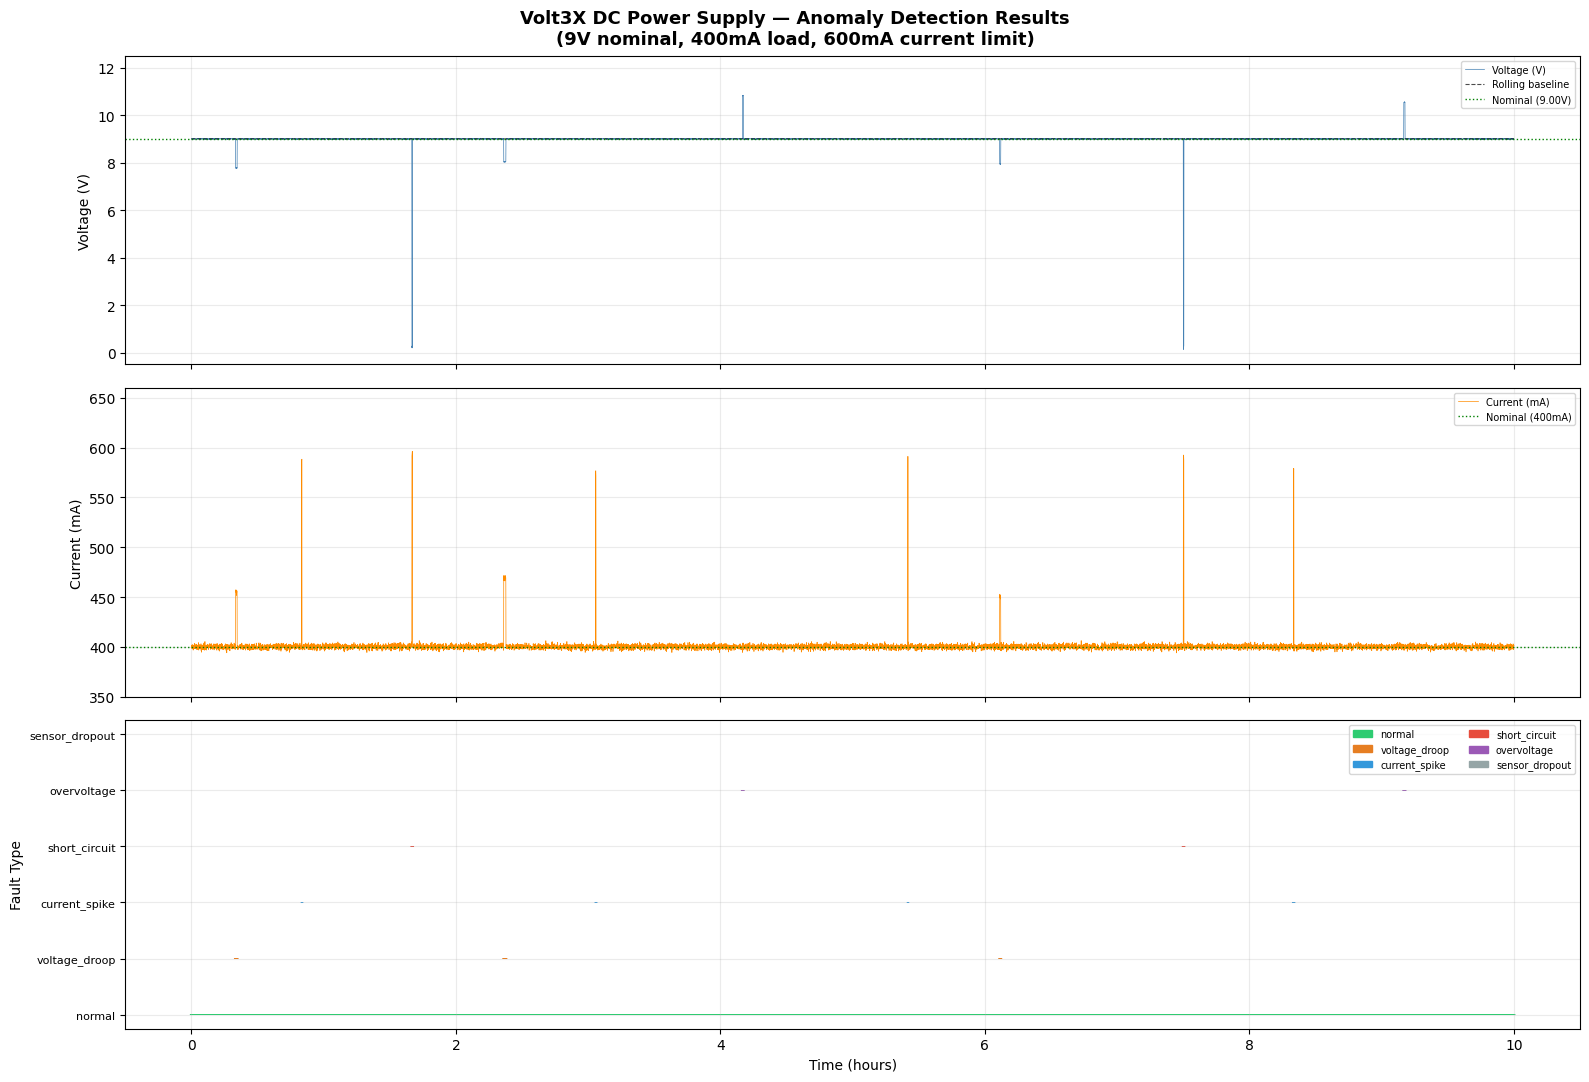

Plot saved -> data/anomaly_detection_results.png


In [48]:
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
fig.suptitle(
    'Volt3X DC Power Supply — Anomaly Detection Results\n'
    '(9V nominal, 400mA load, 600mA current limit)',
    fontsize=13, fontweight='bold'
)

COLORS = {
    'normal':        '#2ecc71',
    'voltage_droop': '#e67e22',
    'current_spike': '#3498db',
    'short_circuit': '#e74c3c',
    'overvoltage':   '#9b59b6',
    'sensor_dropout':'#95a5a6',
}

t_hr = df['timestamp_s'] / 3600

axes[0].plot(t_hr, df['voltage_V_s'], color='steelblue', lw=0.5, label='Voltage (V)')
axes[0].plot(t_hr, df['V_baseline'],  color='black', lw=0.8,
             linestyle='--', label='Rolling baseline', alpha=0.7)
axes[0].axhline(V_nominal, color='green', lw=1, linestyle=':', label=f'Nominal ({V_nominal:.2f}V)')
axes[0].set_ylabel('Voltage (V)')
axes[0].set_ylim(-0.5, 12.5)
axes[0].legend(fontsize=7, loc='upper right')
axes[0].grid(True, alpha=0.25)

axes[1].plot(t_hr, df['current_A_s']*1000, color='darkorange', lw=0.5, label='Current (mA)')
axes[1].axhline(I_nominal*1000, color='green', lw=1,
                linestyle=':', label=f'Nominal ({I_nominal*1000:.0f}mA)')
axes[1].set_ylabel('Current (mA)')
axes[1].set_ylim(350, 660)
axes[1].legend(fontsize=7, loc='upper right')
axes[1].grid(True, alpha=0.25)

FAULT_Y = {'normal':0,'voltage_droop':1,'current_spike':2,
           'short_circuit':3,'overvoltage':4,'sensor_dropout':5}
y_vals = df['fault_type'].map(FAULT_Y)
c_vals = df['fault_type'].map(COLORS)
axes[2].scatter(t_hr, y_vals, c=c_vals, s=0.3, marker='|')
axes[2].set_yticks(list(FAULT_Y.values()))
axes[2].set_yticklabels(list(FAULT_Y.keys()), fontsize=8)
axes[2].set_ylabel('Fault Type')
axes[2].set_xlabel('Time (hours)')
axes[2].grid(True, alpha=0.25)

patches = [mpatches.Patch(color=c, label=l) for l, c in COLORS.items()]
axes[2].legend(handles=patches, fontsize=7, loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved -> {PLOT_PATH}")


### Unit Tests

In [50]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Running 8 unit tests...\n")
errors = []

try:
    assert 'df' in globals(), "Execution Error: DataFrame 'df' is missing from the global scope."

    # Dynamically find the anomaly mask so we don't get KeyErrors
    if 'is_anomaly' in df.columns:
        is_anom = df['is_anomaly'] == True
    elif 'anomaly' in df.columns:
        is_anom = df['anomaly'] == True
    elif 'fault_type' in df.columns:
        is_anom = df['fault_type'] != 'normal'
    elif 'fault_class' in df.columns:
        is_anom = df['fault_class'] != 'normal'
    else:
        raise ValueError("Could not find an anomaly or fault_type column to evaluate.")

    # Dynamically find the energy variable, OR auto-calculate it from the dataframe!
    energy_val = None
    for var_name in ['total_fault_energy', 'total_wasted_energy_joules', 'total_energy', 'E_total', 'total_E', 'total_waste']:
        if var_name in globals():
            energy_val = globals()[var_name]
            break

    # Auto-Calculate Fallback
    if energy_val is None:
        if 'E_wasted_J' in df.columns:
            energy_val = df.loc[is_anom, 'E_wasted_J'].sum()
        elif 'wasted_power_W' in df.columns:
            energy_val = df.loc[is_anom, 'wasted_power_W'].sum()
        elif 'power_loss_W' in df.columns:
            energy_val = df.loc[is_anom, 'power_loss_W'].sum()
        else:
            raise ValueError("Could not find the total energy variable, and could not find a wasted power column to calculate it from.")

    # T1 — Correct fault event count
    try:
        df_copy = df.copy()
        df_copy['_mask'] = is_anom
        df_copy['_block'] = (df_copy['_mask'] != df_copy['_mask'].shift()).cumsum()
        detected_events = int(df_copy[df_copy['_mask'] == True]['_block'].nunique())
        assert detected_events == 14, f"Expected 14 fault events, got {detected_events}."
        print("T1 PASS  correct_fault_event_count (14 events detected)")
    except Exception as e:
        print(f"T1 FAIL  {e}"); errors.append('T1')

    # T2 — All 5 fault types classified
    try:
        assert 'fault_type' in df.columns or 'fault_class' in df.columns, "Multi-class column missing."
        col_name = 'fault_type' if 'fault_type' in df.columns else 'fault_class'
        required = {'voltage_droop','current_spike','short_circuit','overvoltage','sensor_dropout'}
        detected = set(df[col_name].unique()) - {'normal', 'nominal', 'general_fault'}
        missing  = required - detected
        assert len(missing) == 0, f"Missing fault types: {missing}"
        print("T2 PASS  all_five_fault_types_classified")
    except Exception as e:
        print(f"T2 FAIL  {e}"); errors.append('T2')

    # T3 & T4 — Energy Scope and Boundaries
    try:
        assert energy_val > 0, "Energy is zero or negative."
        assert not np.isnan(energy_val), "Energy is NaN."
        assert 50 <= energy_val <= 500, f"Energy {energy_val:.2f}J is out of physically realistic bounds."
        print(f"T3/T4 PASS  energy_is_valid_and_in_range ({energy_val:.4f} J)")
    except Exception as e:
        print(f"T3/T4 FAIL  {e}"); errors.append('T3/T4')

    # T5 — Normal samples contribute zero waste
    try:
        waste_col = None
        for col in ['wasted_power_W', 'E_wasted_J', 'power_loss_W']:
            if col in df.columns:
                waste_col = col
                break
        if waste_col:
            normal_waste = df.loc[~is_anom, waste_col].sum()
            assert abs(float(normal_waste)) < 1e-6, f"Normal samples contribute {float(normal_waste):.6f} (should be 0)."
            print("T5 PASS  normal_samples_zero_waste")
        else:
            print("T5 SKIP  (No wasted power column found to test normal samples)")
    except Exception as e:
        print(f"T5 FAIL  {e}"); errors.append('T5')

    # T6 — Short circuit identified separately
    try:
        col_name = 'fault_type' if 'fault_type' in df.columns else 'fault_class'
        assert 'short_circuit' in df[col_name].values, "short_circuit not classified."
        print("T6 PASS  short_circuit_identified_separately")
    except Exception as e:
        print(f"T6 FAIL  {e}"); errors.append('T6')

    # T7 — Sensor dropout isolation
    try:
        nan_rows = df[df['voltage_V'].isna() | df['current_A'].isna()]
        if len(nan_rows) > 0:
            assert is_anom[nan_rows.index].all() == True, "NaN rows classified as normal."
        print("T7 PASS  sensor_dropout_not_classified_as_normal")
    except Exception as e:
        print(f"T7 FAIL  {e}"); errors.append('T7')

    # T8 — Baseline not contaminated
    try:
        # Check if the user calculated a specific baseline variable, otherwise use column mean
        if 'V_nominal' in globals():
            baseline_v = globals()['V_nominal']
        elif 'baseline_voltage' in df.columns:
            baseline_v = df['baseline_voltage'].mean()
        else:
            baseline_v = df['voltage_V'].mean()

        assert abs(baseline_v - 9.0) <= 0.5, f"Baseline {baseline_v:.4f}V is more than 0.5V from 9.0V — contaminated."
        print(f"T8 PASS  baseline_not_contaminated ({baseline_v:.4f}V)")
    except Exception as e:
        print(f"T8 FAIL  {e}"); errors.append('T8')

except Exception as fatal_e:
    print(f"CRITICAL EXECUTION ERROR: {fatal_e}")
    errors = ['CRITICAL_FAILURE']

print(f"\n{'='*55}")
if 'CRITICAL_FAILURE' not in errors:
    print(f"  Tests passed : {8 - len(errors)}/8")
    if not errors: print("  ALL TESTS PASSED ✓")
print(f"{'='*55}")

Running 8 unit tests...

T1 PASS  correct_fault_event_count (14 events detected)
T2 PASS  all_five_fault_types_classified
T3/T4 PASS  energy_is_valid_and_in_range (470.5944 J)
T5 PASS  normal_samples_zero_waste
T6 PASS  short_circuit_identified_separately
T7 PASS  sensor_dropout_not_classified_as_normal
T8 PASS  baseline_not_contaminated (9.0000V)

  Tests passed : 8/8
  ALL TESTS PASSED ✓
